# IFS HRES & GraphCast Ablation & Comparison

This notebook produces plots for:
1. IFS HRES and Graphcast comparison for ERA5 and IFS reference.
2. Surface pressure ablation (Hypsometric vs Reference).
3. Hydrostatic temperature ablation (Dry T vs Virtual Tv).
4. Effective resolution threshold ablation study.

In [1]:
import sys
import argparse
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Setup plotting style
sns.set_theme(style="whitegrid")
%matplotlib inline

# Define base directories
REPO_ROOT = Path.cwd()
BASE_DIR = REPO_ROOT / "Notebook" / "Data"
ERA5_DIR = BASE_DIR / "ERA5"
IFS_DIR = BASE_DIR / "IFS"
ABLA_SP_DIR = BASE_DIR / "Ablation_sp"
ABLA_TV_DIR = BASE_DIR / "Ablation_Tv"

PLOTS_DIR = REPO_ROOT / "plots"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

EARTH_RADIUS_KM = 6371.0
MODELS = ["hres", "graphcast"]
NICE = {"hres": "HRES", "graphcast": "GraphCast"}
MODEL_STYLES = {
    "graphcast": {"color": "#000000", "marker": "D"},
    "hres":      {"color": "#56B4E9", "marker": "P"},
    "ifs_ablation_hypso": {"color": "#D55E00", "marker": "s"},
    "ifs_ablation_refsp": {"color": "#009E73", "marker": "^"}
}

## General Comparison: ERA5 vs IFS Reference

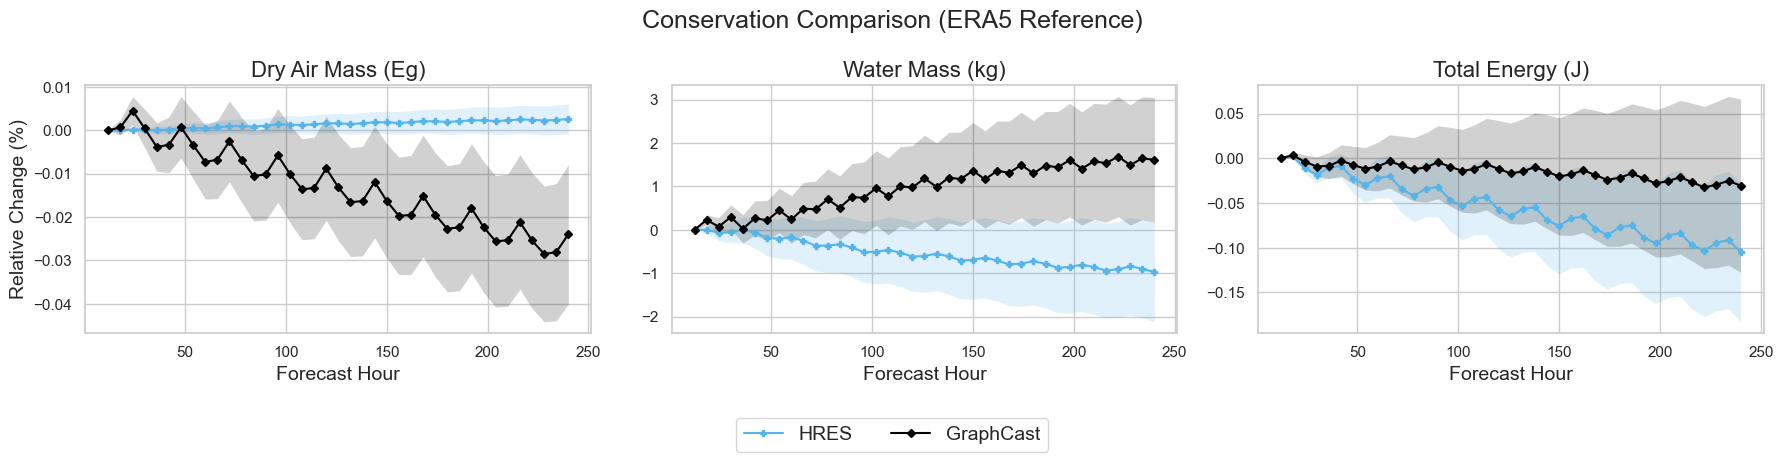

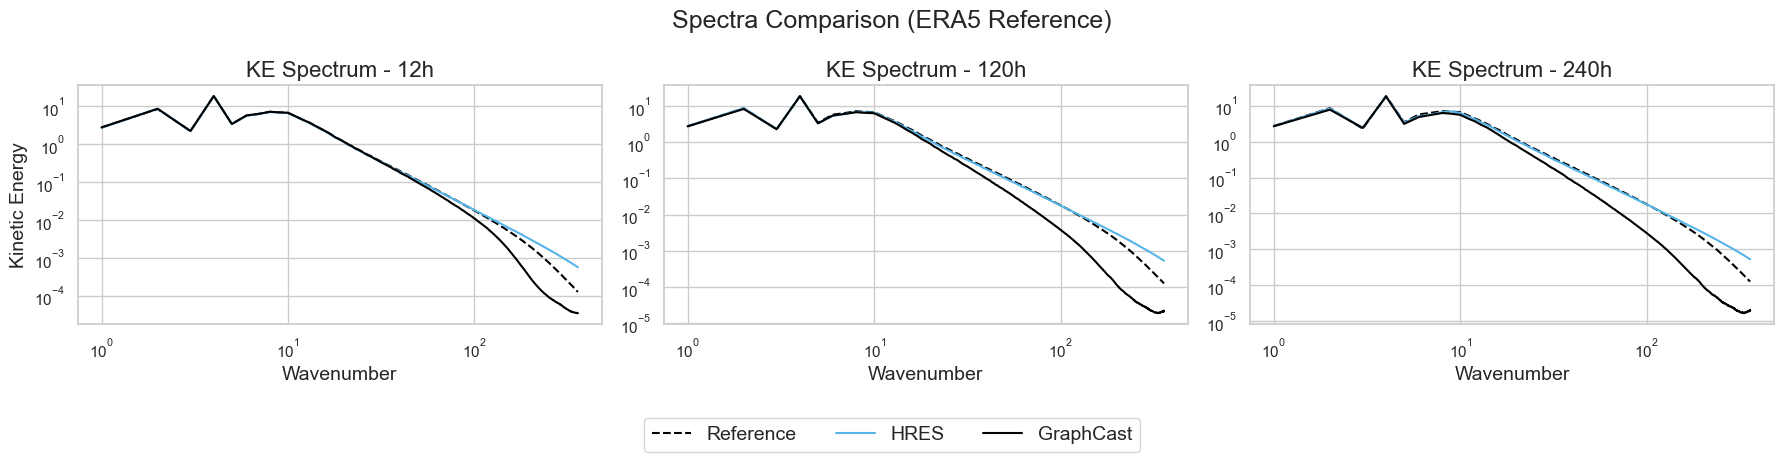

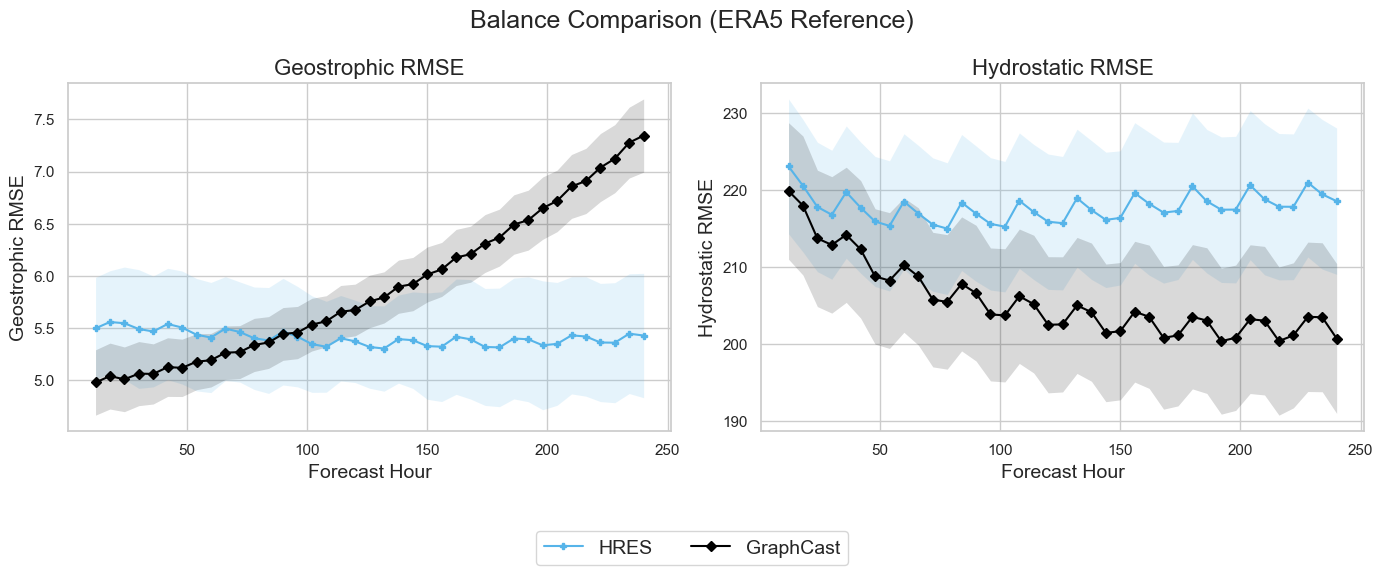

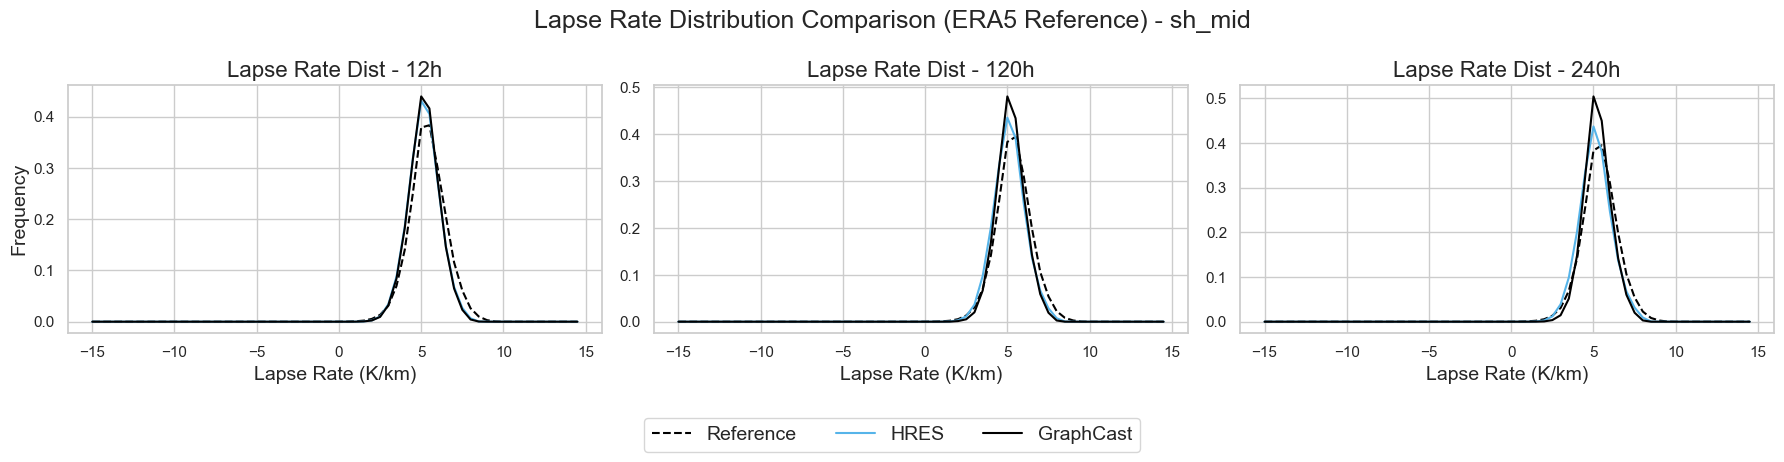

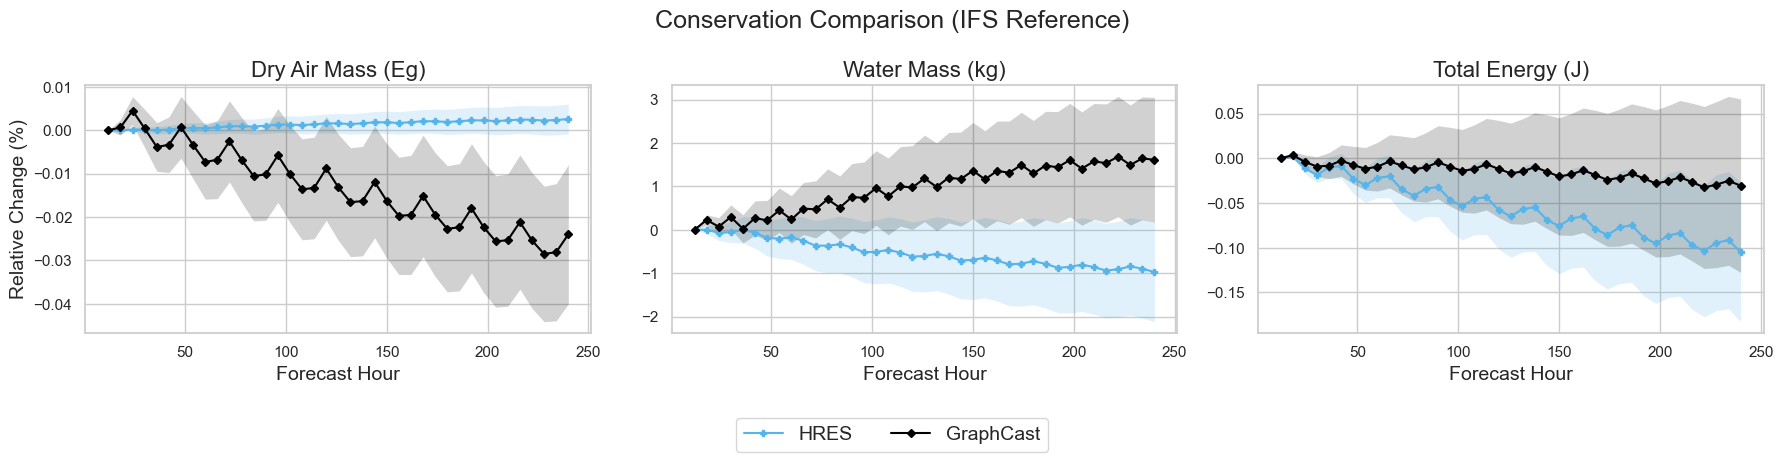

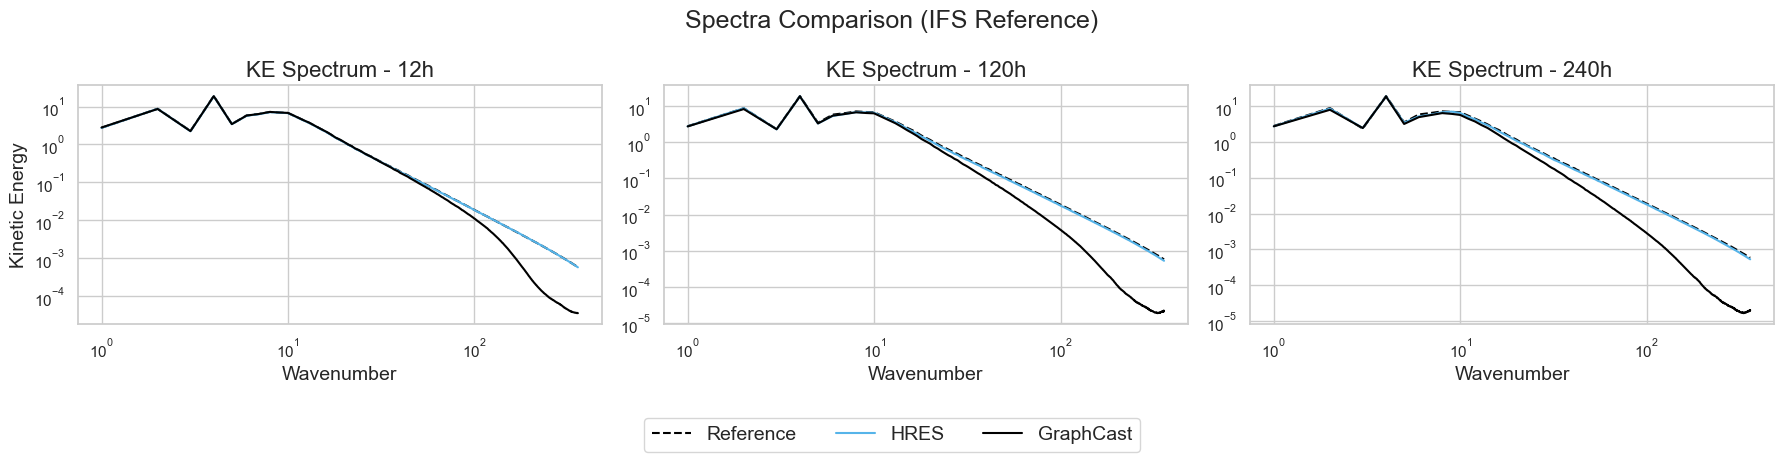

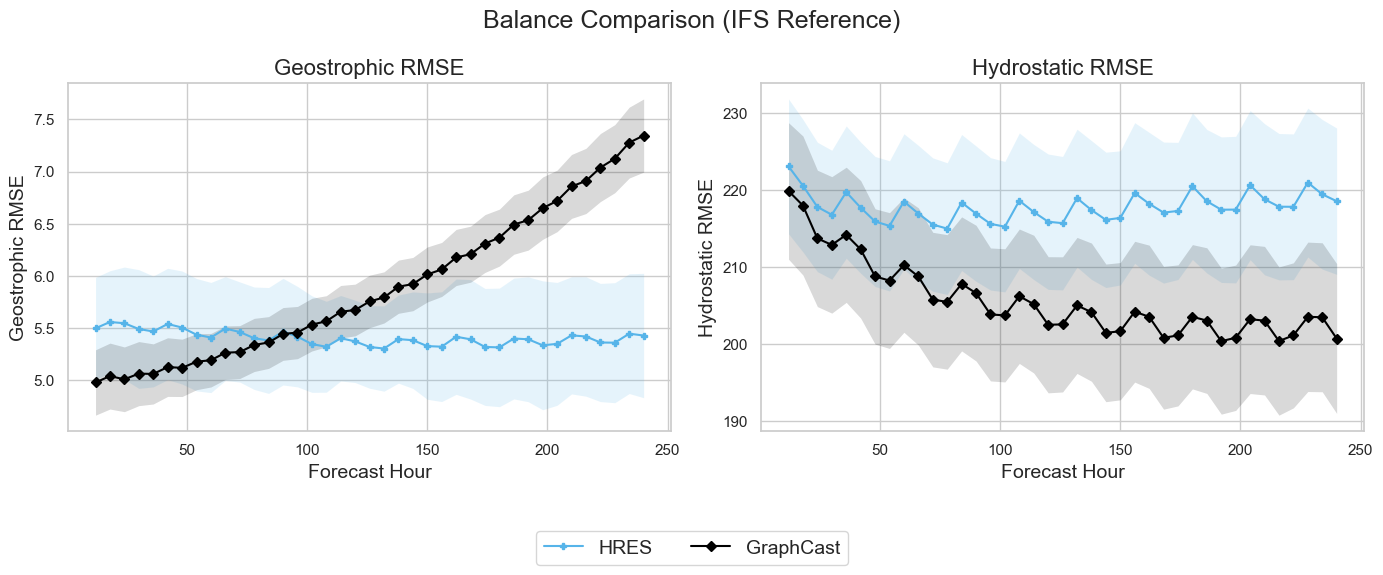

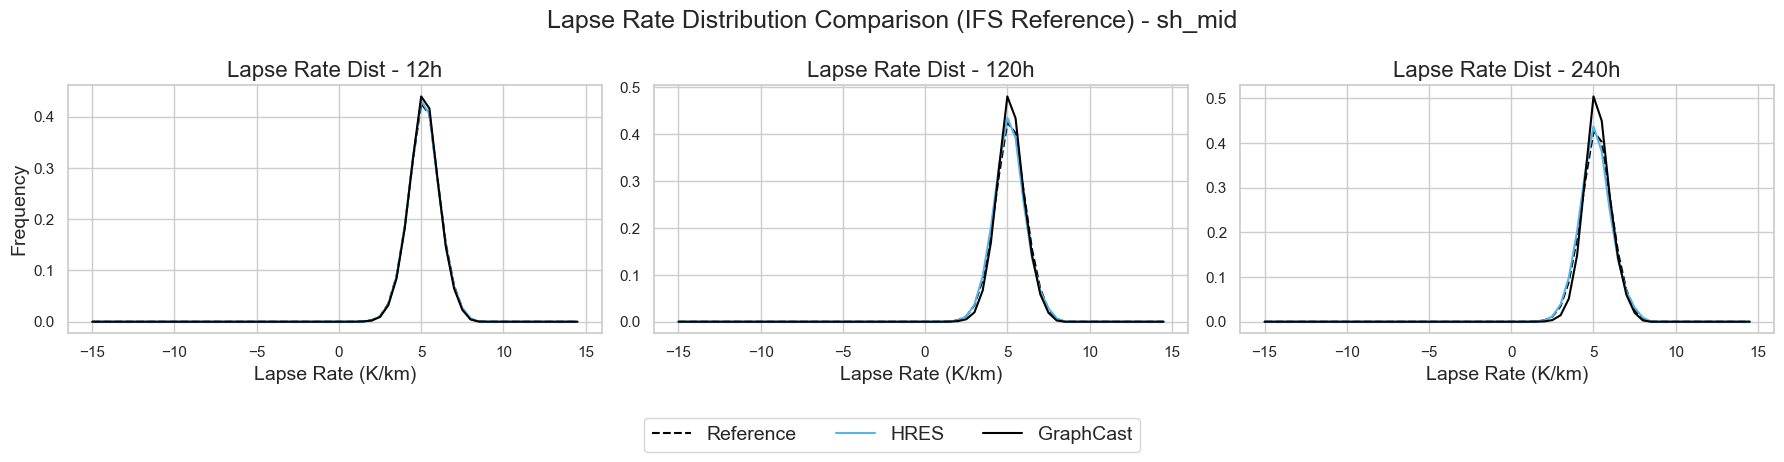

In [2]:
def plot_combined_conservation(results_dir, reference_name):
    frames = []
    for m in MODELS:
        for path in results_dir.glob(f"time_series_{m}_*.csv"):
            df = pd.read_csv(path)
            df["model"] = m
            frames.append(df)
            
    if not frames: 
        print(f"No timeseries data found for {reference_name}.")
        return
    df_all = pd.concat(frames, ignore_index=True)

    metrics = [("dry_mass_Eg", "Dry Air Mass (Eg)"),
               ("water_mass_kg", "Water Mass (kg)"),
               ("total_energy_J", "Total Energy (J)")]
               
    fig, axes = plt.subplots(1, 3, figsize=(18, 4))
    
    for ax, (col, title) in zip(axes, metrics):
        for model in MODELS:
            mdf = df_all[df_all["model"] == model]
            if mdf.empty or col not in mdf.columns: continue
            
            rel_df = mdf[["date", "forecast_hour", col]].dropna().copy()
            if rel_df.empty: continue
            base = rel_df.sort_values("forecast_hour").groupby("date", as_index=False).first()[["date", col]].rename(columns={col: "base_val"})
            rel_df = rel_df.merge(base, on="date", how="left")
            rel_df = rel_df[rel_df["base_val"].abs() > 0]
            if rel_df.empty: continue
            
            rel_df["rel_pct"] = (rel_df[col] - rel_df["base_val"]) / rel_df["base_val"] * 100.0
            agg = rel_df.groupby("forecast_hour")["rel_pct"].agg(["mean", "std"]).reset_index()
            
            style = MODEL_STYLES.get(model, {"color": "grey", "marker": "."})
            ax.plot(agg["forecast_hour"], agg["mean"], label=NICE.get(model, model), color=style["color"], marker=style["marker"], markersize=4)
            ax.fill_between(agg["forecast_hour"], agg["mean"] - agg["std"].fillna(0), agg["mean"] + agg["std"].fillna(0), color=style["color"], alpha=0.18, linewidth=0)
            
        ax.set_title(title, fontsize=16)
        ax.set_xlabel("Forecast Hour", fontsize=14)
        if ax == axes[0]: ax.set_ylabel("Relative Change (%)", fontsize=14)

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, -0.15), ncol=len(labels), fontsize=14)
    fig.suptitle(f"Conservation Comparison ({reference_name} Reference)", fontsize=18)
    fig.tight_layout()
    plt.savefig(PLOTS_DIR / f"conservation_{reference_name}.png", bbox_inches="tight")
    plt.show()

def plot_combined_spectra(results_dir, reference_name):
    frames = []
    for m in MODELS:
        for path in results_dir.glob(f"spectra_{m}_*.csv"):
            df = pd.read_csv(path)
            df["model"] = m
            frames.append(df)
            
    if not frames: return
    df_all = pd.concat(frames, ignore_index=True)
    if "variable" in df_all.columns:
        df_all = df_all[(df_all["variable"] == "KE") & (df_all["wavenumber"] > 0)]
        
    leads = [12, 120, 240]
    fig, axes = plt.subplots(1, 3, figsize=(18, 4))
    
    for ax, lt in zip(axes, leads):
        sub = df_all[df_all["lead_hours"] == lt]
        if sub.empty: continue
            
        ref_agg = sub.groupby("wavenumber")["power_ref"].mean().reset_index()
        if not ref_agg.empty:
            ax.plot(ref_agg["wavenumber"], ref_agg["power_ref"], color="black", linestyle="--", label="Reference")
            
        for model in MODELS:
            msub = sub[sub["model"] == model]
            if msub.empty: continue
            agg = msub.groupby("wavenumber")["power_pred"].mean().reset_index()
            style = MODEL_STYLES.get(model, {"color": "grey", "marker": "."})
            ax.plot(agg["wavenumber"], agg["power_pred"], label=NICE.get(model, model), color=style["color"])
            
        ax.set_title(f"KE Spectrum - {lt}h", fontsize=16)
        ax.set_xlabel("Wavenumber", fontsize=14)
        ax.set_xscale("log")
        ax.set_yscale("log")
        if ax == axes[0]: ax.set_ylabel("Kinetic Energy", fontsize=14)
            
    handles, labels = axes[2].get_legend_handles_labels()
    fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, -0.15), ncol=len(labels), fontsize=14)
    fig.suptitle(f"Spectra Comparison ({reference_name} Reference)", fontsize=18)
    fig.tight_layout()
    plt.savefig(PLOTS_DIR / f"spectra_{reference_name}.png", bbox_inches="tight")
    plt.show()

def plot_combined_balance(results_dir, reference_name):
    frames = []
    for m in MODELS:
        for path in results_dir.glob(f"time_series_{m}_*.csv"):
            df = pd.read_csv(path)
            df["model"] = m
            frames.append(df)
            
    if not frames: return
    df_all = pd.concat(frames, ignore_index=True)
    
    metrics = [("geostrophic_rmse", "Geostrophic RMSE"),
               ("hydrostatic_rmse", "Hydrostatic RMSE")]
               
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    for ax, (col, title) in zip(axes, metrics):
        for model in MODELS:
            mdf = df_all[df_all["model"] == model]
            if mdf.empty or col not in mdf.columns: continue
            
            # Using raw values directly
            rel_df = mdf[["forecast_hour", col]].copy()
            agg = rel_df.groupby("forecast_hour")[col].agg(["mean", "std"]).reset_index()
            
            style = MODEL_STYLES.get(model, {"color": "grey", "marker": "."})
            ax.plot(agg["forecast_hour"], agg["mean"], label=NICE.get(model, model), color=style["color"], marker=style["marker"], markersize=5)
            ax.fill_between(agg["forecast_hour"], agg["mean"] - agg["std"].fillna(0), agg["mean"] + agg["std"].fillna(0), color=style["color"], alpha=0.15, linewidth=0)
            
        ax.set_title(title, fontsize=16)
        ax.set_xlabel("Forecast Hour", fontsize=14)
        ax.set_ylabel(title, fontsize=14)

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, -0.15), ncol=len(labels), fontsize=14)
    fig.suptitle(f"Balance Comparison ({reference_name} Reference)", fontsize=18)
    fig.tight_layout()
    plt.savefig(PLOTS_DIR / f"balance_{reference_name}.png", bbox_inches="tight")
    plt.show()

def plot_combined_lapse_rate(results_dir, reference_name):
    frames = []
    for m in MODELS:
        for path in results_dir.glob(f"lapse_rate_dist_{m}_*.csv"):
            df = pd.read_csv(path)
            df["model"] = m
            frames.append(df)
            
    if not frames: return
    df_all = pd.concat(frames, ignore_index=True)
    
    leads = [12, 120, 240]
    region = "sh_mid"
    df_all = df_all[df_all["region"] == region]
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 4))
    
    for ax, lt in zip(axes, leads):
        sub = df_all[df_all["lead_hours"] == lt]
        if sub.empty: continue
            
        ref_agg = sub.groupby("bin_edge_lower")["freq_ref"].mean().reset_index()
        if not ref_agg.empty:
            ax.plot(ref_agg["bin_edge_lower"], ref_agg["freq_ref"], color="black", linestyle="--", label="Reference")
            
        for model in MODELS:
            msub = sub[sub["model"] == model]
            if msub.empty: continue
            agg = msub.groupby("bin_edge_lower")["freq_pred"].mean().reset_index()
            style = MODEL_STYLES.get(model, {"color": "grey", "marker": "."})
            ax.plot(agg["bin_edge_lower"], agg["freq_pred"], label=NICE.get(model, model), color=style["color"])
            
        ax.set_title(f"Lapse Rate Dist - {lt}h", fontsize=16)
        ax.set_xlabel("Lapse Rate (K/km)", fontsize=14)
        if ax == axes[0]: ax.set_ylabel("Frequency", fontsize=14)
            
    handles, labels = axes[2].get_legend_handles_labels()
    fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, -0.15), ncol=len(labels), fontsize=14)
    fig.suptitle(f"Lapse Rate Distribution Comparison ({reference_name} Reference) - {region}", fontsize=18)
    fig.tight_layout()
    plt.savefig(PLOTS_DIR / f"lapse_rate_dist_{reference_name}.png", bbox_inches="tight")
    plt.show()

# Generate plots for both ERA5 and IFS
for d, name in [(ERA5_DIR, "ERA5"), (IFS_DIR, "IFS")]:
    plot_combined_conservation(d, name)
    plot_combined_spectra(d, name)
    plot_combined_balance(d, name)
    plot_combined_lapse_rate(d, name)

## Surface Pressure Derivation Ablation

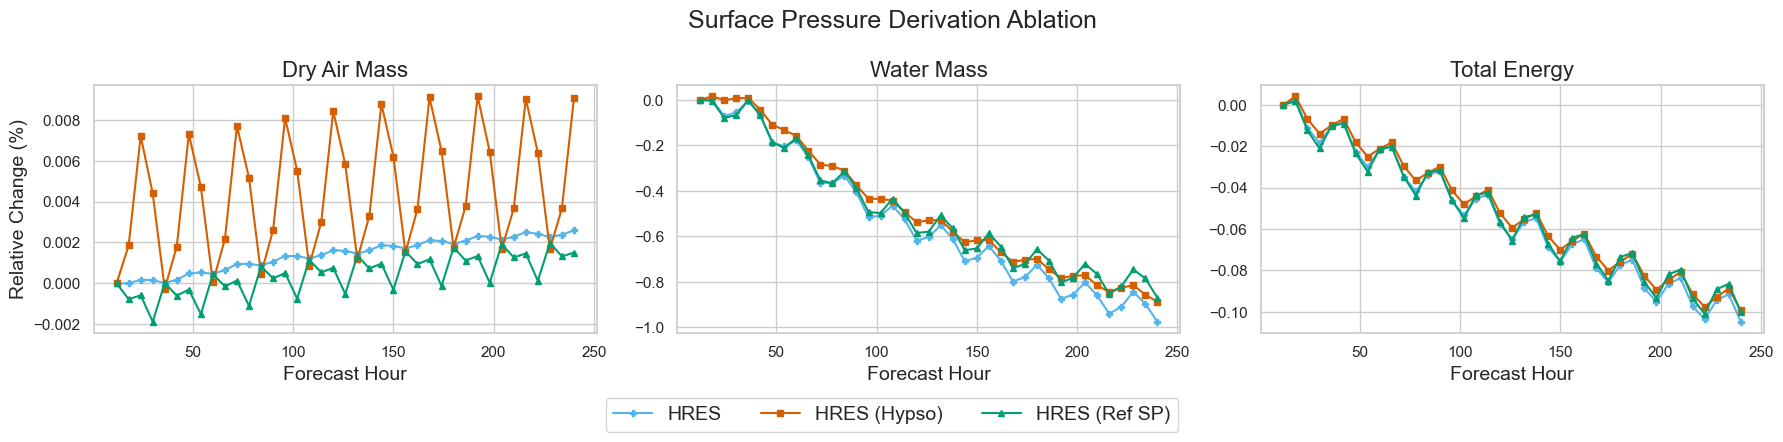

In [3]:
ablation_models = ["hres", "ifs_ablation_hypso", "ifs_ablation_refsp"]
NICE.update({
    "ifs_ablation_hypso": "HRES (Hypso)",
    "ifs_ablation_refsp": "HRES (Ref SP)"
})

frames_sp = []
for m in ablation_models:
    if m == "hres": d = IFS_DIR
    elif m == "ifs_ablation_hypso": d = ABLA_SP_DIR / "Hypsometric"
    elif m == "ifs_ablation_refsp": d = ABLA_SP_DIR / "Reference_sp"
    else: continue
    
    for path in d.glob(f"time_series_{m}_*.csv"):
        df = pd.read_csv(path)
        df["model"] = m
        frames_sp.append(df)

if frames_sp:
    df_sp_all = pd.concat(frames_sp, ignore_index=True)
    fig, axes = plt.subplots(1, 3, figsize=(18, 4))
    metrics = [("dry_mass_Eg", "Dry Air Mass"), ("water_mass_kg", "Water Mass"), ("total_energy_J", "Total Energy")]

    for ax, (col, title) in zip(axes, metrics):
        for model in ablation_models:
            mdf = df_sp_all[df_sp_all["model"] == model]
            if mdf.empty or col not in mdf.columns: continue
            
            rel_df = mdf[["date", "forecast_hour", col]].dropna().copy()
            if rel_df.empty: continue
            base = rel_df.sort_values("forecast_hour").groupby("date", as_index=False).first()[["date", col]].rename(columns={col: "base_val"})
            rel_df = rel_df.merge(base, on="date", how="left")
            rel_df = rel_df[rel_df["base_val"].abs() > 0]
            if rel_df.empty: continue
            
            rel_df["rel_pct"] = (rel_df[col] - rel_df["base_val"]) / rel_df["base_val"] * 100.0
            agg = rel_df.groupby("forecast_hour")["rel_pct"].agg(["mean", "std"]).reset_index()
            style = MODEL_STYLES.get(model, {"color": "grey", "marker": "."})
            ax.plot(agg["forecast_hour"], agg["mean"], label=NICE.get(model, model), color=style["color"], marker=style["marker"], markersize=4)

        ax.set_title(title, fontsize=16)
        ax.set_xlabel("Forecast Hour", fontsize=14)
        if ax == axes[0]: ax.set_ylabel("Relative Change (%)", fontsize=14)

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, -0.1), ncol=len(labels), fontsize=14)
    fig.suptitle("Surface Pressure Derivation Ablation", fontsize=18)
    fig.tight_layout()
    plt.savefig(PLOTS_DIR / "sp_ablation.png", bbox_inches="tight")
    plt.show()
else:
    print("No SP ablation data found.")

## Hydrostatic Temperature Ablation ($T_v$ vs $T$)

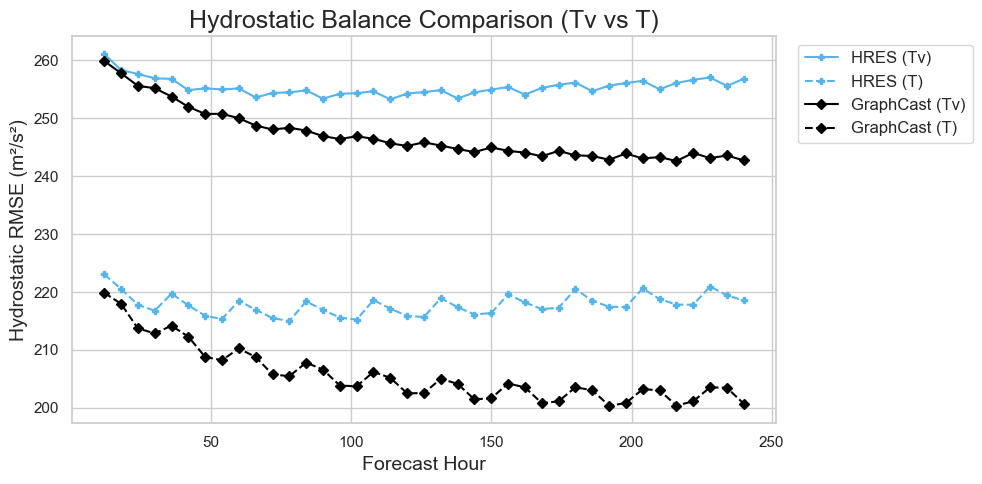

In [4]:
variants = {"Tv": ABLA_TV_DIR, "T": IFS_DIR} # Tv from Ablation Tv, T (Standard) from regular IFS directory. 

hydro_frames = []
for v_name, v_dir in variants.items():
    if not v_dir.exists(): continue
    for m in MODELS:
        for path in v_dir.glob(f"time_series_{m}_*.csv"):
            df = pd.read_csv(path)
            if "hydrostatic_rmse" in df.columns:
                df["variant"] = v_name
                df["model"] = m
                hydro_frames.append(df)

if hydro_frames:
    df_hydro = pd.concat(hydro_frames, ignore_index=True)
    fig, ax = plt.subplots(figsize=(10, 5))
    
    for model in MODELS:
        for v_name in variants.keys():
            mdf = df_hydro[(df_hydro["model"] == model) & (df_hydro["variant"] == v_name)]
            if mdf.empty: continue
            
            agg = mdf.groupby("forecast_hour")["hydrostatic_rmse"].agg(["mean", "std"]).reset_index()
            
            style = MODEL_STYLES.get(model, {"color": "grey", "marker": "."})
            ls = "-" if v_name == "Tv" else "--"
            label = f"{NICE.get(model, model)} ({v_name})"
            
            ax.plot(agg["forecast_hour"], agg["mean"], label=label, color=style["color"], marker=style["marker"], markersize=5, linestyle=ls)
            
    ax.set_title("Hydrostatic Balance Comparison (Tv vs T)", fontsize=18)
    ax.set_xlabel("Forecast Hour", fontsize=14)
    ax.set_ylabel("Hydrostatic RMSE (m²/s²)", fontsize=14)
    ax.legend(fontsize=12, bbox_to_anchor=(1.02, 1), loc="upper left")
    fig.tight_layout()
    plt.savefig(PLOTS_DIR / "hydro_temperature_ablation.png", bbox_inches="tight")
    plt.show()
else:
    print("No hydrostatic ablation data found.")

## Effective Resolution Threshold Ablation

In [5]:
def _find_effective_resolution(k, e_pred, e_true, threshold, n_consecutive):
    with np.errstate(divide="ignore", invalid="ignore"):
        ratio = e_pred / e_true
    
    below = ratio < threshold
    n = len(ratio)
    fallback = 2.0 * np.pi * EARTH_RADIUS_KM / (float(k[-1]) if len(k) else 1.0)

    if n < n_consecutive:
        return fallback

    run = 0
    for i in range(n):
        if below[i]:
            run += 1
            if run >= n_consecutive:
                idx = i - n_consecutive + 1
                return 2.0 * np.pi * EARTH_RADIUS_KM / float(k[idx])
        else:
            run = 0
            
    return fallback

thresholds = [0.1, 0.3, 0.5, 0.7, 0.9]
n_consecutive_vals = [1, 3, 5, 7]
leads = [12, 120, 240]

results = []
for model in ["graphcast"]:
    # Use ERA5 spectra for reference
    filepaths = list(ERA5_DIR.glob(f"spectra_{model}_*.csv"))
    if not filepaths: continue
    
    df = pd.read_csv(filepaths[0])
    if "variable" in df.columns:
        df = df[df["variable"] == "KE"]
    
    for lead in leads:
        sub_df = df[df["lead_hours"] == lead]
        if sub_df.empty: continue
            
        agg = sub_df.groupby("wavenumber")[["power_pred", "power_ref"]].mean().reset_index()
        agg = agg[agg["power_ref"] > 1e-12].sort_values("wavenumber")
        
        k = agg["wavenumber"].values
        e_pred = agg["power_pred"].values
        e_ref = agg["power_ref"].values
        
        for thr in thresholds:
            for n in n_consecutive_vals:
                eff_res = _find_effective_resolution(k, e_pred, e_ref, thr, n)
                results.append({
                    "Model": model,
                    "lead_hours": lead,
                    "threshold": thr,
                    "n_consecutive": n,
                    "eff_res": eff_res
                })

if results:
    df_results = pd.DataFrame(results)
    pd.set_option('display.max_rows', 500)
    print("Computed effective resolutions:")
    display(df_results)
else:
    print("No valid spectra data found to run effective resolution ablation.")

Computed effective resolutions:


,Model,lead_hours,threshold,n_consecutive,eff_res
0,graphcast,12,0.1,1,111.504662
1,graphcast,12,0.1,3,111.504662
2,graphcast,12,0.1,5,111.504662
3,graphcast,12,0.1,7,111.504662
4,graphcast,12,0.3,1,254.969259
5,graphcast,12,0.3,3,254.969259
6,graphcast,12,0.3,5,254.969259
7,graphcast,12,0.3,7,254.969259
8,graphcast,12,0.5,1,328.116177
9,graphcast,12,0.5,3,328.116177
